# MNIST Pixel Graph — Selection via Standardized Hessian

Recover a graph over the 28x28 MNIST pixel grid from a trained DDPM's Hessian.

**Pipeline** (implemented in `mnist_graph.py`):
1. For one anchor pixel, the standardized `|H[i, j]|` trajectories separate by
   L1 grid distance — locality is visible in the Hessian.
2. Over *all* pixel pairs, KMeans on standardized `|H|` recovers a coherent
   high-magnitude cluster.
3. That cluster, drawn on the 28x28 grid, is the selected graph.

The notebook keeps only the plotting; data is self-contained under `./data/`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection

import mnist_graph as mg
from mnist_graph import GRID, N_PIX, T_LIST, ANCHOR_ROW, ANCHOR_COL

# ---- run the pipeline (see mnist_graph.py) ----
H_dict_avg, hessian_path = mg.load_hessian()
img28 = mg.load_reference_image()
print(f"Loaded Hessian: {hessian_path.split('/')[-1]}")
print(f"timesteps: t={T_LIST[0]}..{T_LIST[-1]} (count={len(T_LIST)})")

records = mg.anchor_trajectories(H_dict_avg)   # |H[anchor, j]| trajectories + z-scores
cluster = mg.global_clustering(H_dict_avg)     # KMeans(K=2) over all pixel pairs
graph = mg.selected_graph(cluster)             # high-magnitude cluster as a grid graph

segments = graph["segments"]                   # (n_sel, 2, 2) line segments in (col, row)
edge_l1 = graph["edge_l1"]                     # L1 grid distance per selected edge

print(f"global pairs: {cluster['iu'].size:,}")
print(f"selected (high-magnitude) edges: {graph['sel'].size:,}")

Loaded Hessian: hessian_mnist_mnist_unet_ddpm_epoch50_x0_128_bx0_8_S_5000.pickle
timesteps: t=1..30 (count=30)
global pairs: 306,936
selected (high-magnitude) edges: 640


## Figures

Three presentation-ready figures:
- **(a)** an annotated locality figure marking the anchor and its L1=1 / L1=2 neighbors;
- **(b)** a 3-bucket standardized `|H|` plot (L1=1, L1=2, L1>=3);
- **(c)** a plain-grid view of the selected short-range graph.

All three share one bucket spec (`BUCKETS`), defined once below.

In [2]:
# Bucket spec for the L1-distance views (single source of truth).
BUCKETS = {
    "d1":   {"color": "#08306b", "lw": 1.6, "alpha": 0.95, "z": 3,
             "label": r"$\ell^{1}$-distance $= 1$"},
    "d2":   {"color": "#4292c6", "lw": 1.6, "alpha": 0.95, "z": 2,
             "label": r"$\ell^{1}$-distance $= 2$"},
    "dge3": {"color": "#a50f15", "lw": 1.0, "alpha": 0.30, "z": 0,
             "label": r"$\ell^{1}$-distance $\geq 3$"},
}
BUCKET_ORDER = ["dge3", "d2", "d1"]   # draw order: back -> front


def bucket_of(d):
    """Map an L1 distance to its bucket key."""
    if d == 1:
        return "d1"
    if d == 2:
        return "d2"
    return "dge3"

### (a) Locality figure with L1 neighbors and grid coordinates

The reference digit with the anchor (gold), its L1=1 and L1=2 neighbors, and the
grid-coordinate corners (1,1) and (28,28) annotated.

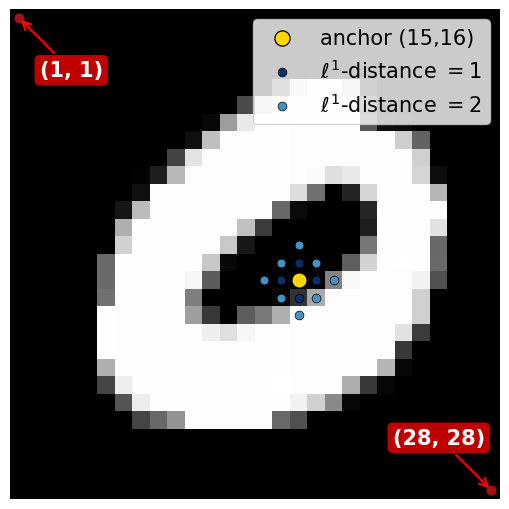

In [3]:
# All 28x28 pixel coordinates and their L1 distance to the anchor
rr, cc = np.mgrid[0:GRID, 0:GRID]
l1 = np.abs(rr - ANCHOR_ROW) + np.abs(cc - ANCHOR_COL)
d1_r, d1_c = np.where(l1 == 1)
d2_r, d2_c = np.where(l1 == 2)

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.imshow(img28, cmap="gray", interpolation="nearest")

# L1 = 2 then L1 = 1 neighbors (drawn under the anchor)
h_d2 = ax.scatter(d2_c, d2_r, c=BUCKETS["d2"]["color"], s=40,
                  edgecolors="black", linewidths=0.5, zorder=3, label=BUCKETS["d2"]["label"])
h_d1 = ax.scatter(d1_c, d1_r, c=BUCKETS["d1"]["color"], s=40,
                  edgecolors="black", linewidths=0.5, zorder=4, label=BUCKETS["d1"]["label"])
h_anchor = ax.scatter([ANCHOR_COL], [ANCHOR_ROW], c="gold", s=120,
                      edgecolors="black", linewidths=0.9, zorder=5,
                      label=f"anchor ({ANCHOR_ROW},{ANCHOR_COL})")

# Grid-coordinate corners: top-left = (1,1), bottom-right = (28,28)
# (imshow is 0-indexed: pixel centers (0,0) and (27,27))
ax.scatter([0, GRID - 1], [0, GRID - 1], c="#a50f15", s=40)
ax.annotate("(1, 1)", xy=(0, 0), xytext=(3, 3),
            fontsize=15, fontweight="bold", color="white", ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.25", fc="red", ec="none", alpha=0.75),
            arrowprops=dict(arrowstyle="->", color="red", lw=1.5))
ax.annotate("(28, 28)", xy=(GRID - 1, GRID - 1), xytext=(GRID - 4, GRID - 4),
            fontsize=15, fontweight="bold", color="white", ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.25", fc="red", ec="none", alpha=0.75),
            arrowprops=dict(arrowstyle="->", color="red", lw=1.5))

ax.legend(handles=[h_anchor, h_d1, h_d2], loc="upper right", fontsize=15, frameon=True)
ax.axis("off")
plt.tight_layout()
plt.show()

### (b) Standardized `|H|` — 3 buckets (L1 = 1, 2, >= 3)

The anchor's standardized `|H[anchor, j]|` trajectories, grouped into three L1
buckets and drawn back-to-front so the close (high-magnitude) pairs sit on top.

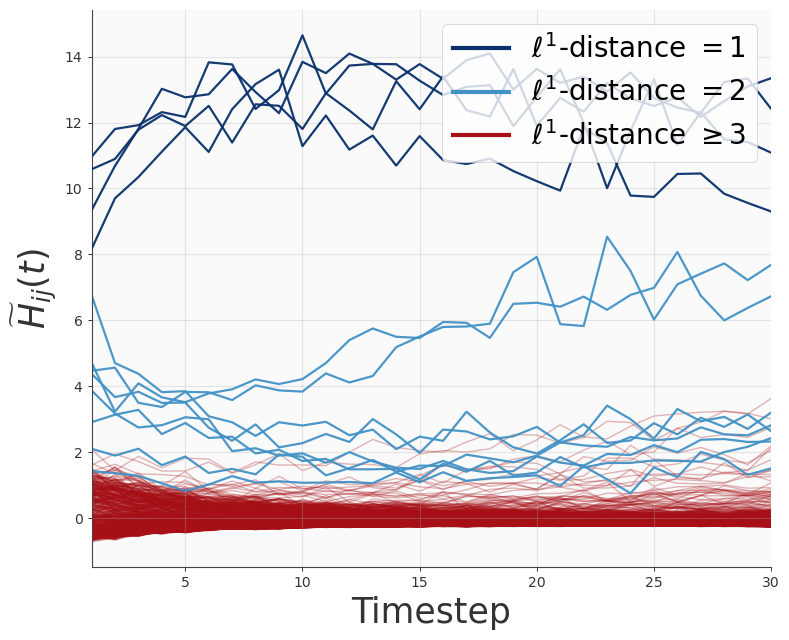

In [4]:
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.set_facecolor("#fafafa")

# Draw bucket-by-bucket so the background bucket stays under the foreground ones
for b in BUCKET_ORDER:
    spec = BUCKETS[b]
    for rec in records:
        if bucket_of(rec["l1"]) != b:
            continue
        ax.plot(T_LIST, rec["vals_std"], color=spec["color"], linewidth=spec["lw"],
                alpha=spec["alpha"], zorder=spec["z"], solid_capstyle="round")

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#444"); ax.spines[spine].set_linewidth(0.8)
ax.tick_params(axis="both", length=3, width=0.7, colors="#333", labelsize=10)
ax.set_axisbelow(True)
ax.set_xlabel("Timestep", fontsize=25, color="#333")
ax.set_ylabel(r"$\widetilde H_{ij}(t)$", fontsize=25, color="#333")

all_vals = np.asarray([rec["vals_std"] for rec in records])
y_lo, y_hi = all_vals.min(), all_vals.max()
pad = 0.05 * (y_hi - y_lo)
ax.set_ylim(y_lo - pad, y_hi + pad)
ax.set_xlim(min(T_LIST), max(T_LIST))

legend_handles = [Line2D([0], [0], color=BUCKETS[b]["color"], lw=3, label=BUCKETS[b]["label"])
                  for b in ("d1", "d2", "dge3")]
leg = ax.legend(handles=legend_handles, loc="upper right", fontsize=20,
                frameon=True, framealpha=0.8, edgecolor="#cccccc")
leg.get_frame().set_linewidth(0.6)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### (c) Selected short-range graph — plain grid

The L1<=4 selected graph on a bare 28x28 grid (no digit background). L1=1 and
L1=2 edges share one color; node size scales with degree.

Short-range edges (L1<=4) among selected: 640


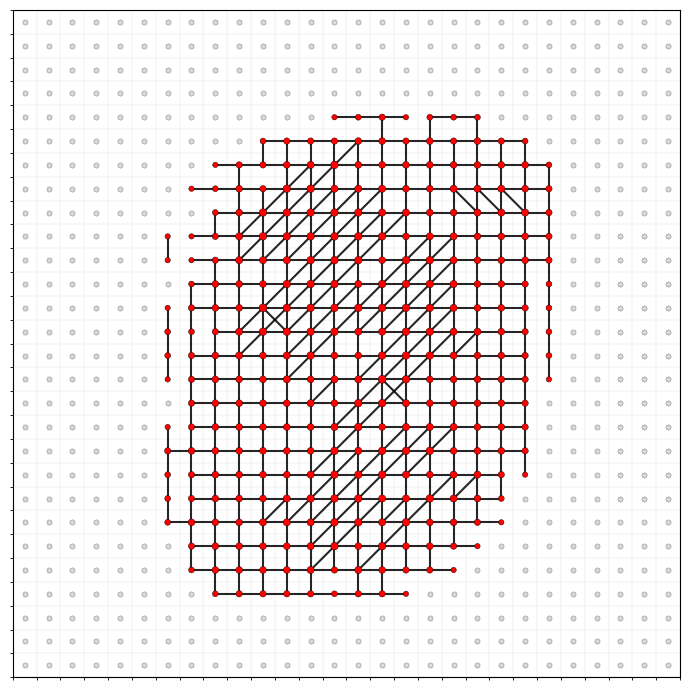

In [5]:
short_mask = edge_l1 <= 4
print(f"Short-range edges (L1<=4) among selected: {int(short_mask.sum()):,}")

# L1 in {1,2} share black; L1 = 3, 4 keep distinct colors
SHORT_COLORS = {1: "black", 2: "black", 3: "#7570b3", 4: "#e7298a"}
seg_colors = np.array([SHORT_COLORS[d] for d in edge_l1[short_mask]])

deg_s_grid = mg.degree_grid_for_mask(cluster, graph, short_mask)
conn_r, conn_c = np.where(deg_s_grid > 0)
unconn_r, unconn_c = np.where(deg_s_grid == 0)

XLIM = (-0.5, GRID - 0.5)
YLIM = (GRID - 0.5, -0.5)   # row 0 at top, like imshow

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_facecolor("white")
ax.set_xticks(np.arange(-0.5, GRID, 1), minor=True)
ax.set_yticks(np.arange(-0.5, GRID, 1), minor=True)
ax.grid(which="minor", color="lightgray", linewidth=0.3, alpha=0.7)

ax.add_collection(LineCollection(segments[short_mask], colors=seg_colors,
                                 linewidths=1.5, alpha=0.85))
ax.scatter(unconn_c, unconn_r, s=14, c="lightgray", edgecolors="dimgray",
           linewidths=0.3, alpha=0.9, zorder=2)
ax.scatter(conn_c, conn_r, s=12 + 3.0 * deg_s_grid[conn_r, conn_c], c="red",
           edgecolors="black", linewidths=0.3, zorder=3)

ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
ax.set_aspect("equal", adjustable="box")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

### (d) DDPM samples vs real MNIST

Samples from the trained DDPM next to real MNIST training images. The samples
were generated once from the checkpoint and saved under `./data/`, so this view
needs neither the checkpoint nor a GPU to reproduce.

generated: (35, 28, 28), real: (35, 28, 28)


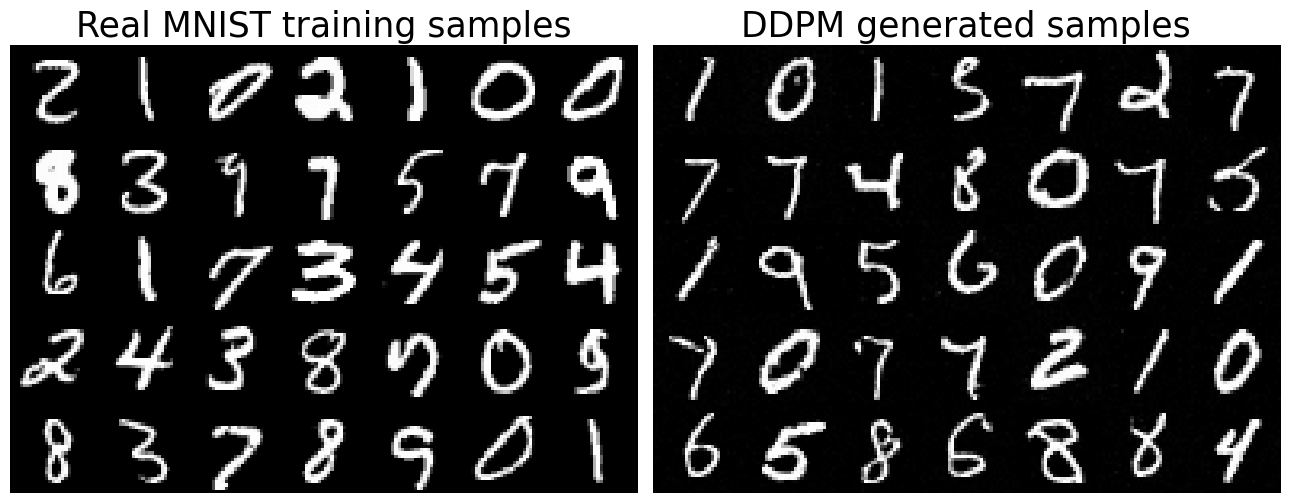

In [6]:
import math

# Samples pre-generated from the trained DDPM checkpoint and saved under ./data/.
gen_imgs = np.load(mg.DATA_DIR + "/mnist_ddpm_generated.npy")   # (N, 28, 28) in [0, 1]
real_imgs = np.load(mg.DATA_DIR + "/mnist_real_samples.npy")    # (N, 28, 28) in [0, 1]
num_samples = gen_imgs.shape[0]
print(f"generated: {gen_imgs.shape}, real: {real_imgs.shape}")


def make_grid(imgs, nrow):
    """Tile (N, 28, 28) images into a single (nrow*28, ncol*28) array."""
    n, h, w = imgs.shape
    ncol = math.ceil(n / nrow)
    grid = np.ones((nrow * h, ncol * w), dtype=np.float32)
    for k in range(n):
        r, c = divmod(k, ncol)
        grid[r * h:(r + 1) * h, c * w:(c + 1) * w] = imgs[k]
    return grid


nrow = int(math.sqrt(num_samples))
real_grid = make_grid(real_imgs, nrow)
gen_grid = make_grid(gen_imgs, nrow)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.6))
axes[0].imshow(real_grid, cmap="gray", interpolation="nearest")
axes[0].set_title("Real MNIST training samples", fontsize=25)
axes[0].axis("off")
axes[1].imshow(gen_grid, cmap="gray", interpolation="nearest")
axes[1].set_title("DDPM generated samples", fontsize=25)
axes[1].axis("off")
plt.tight_layout()
plt.show()